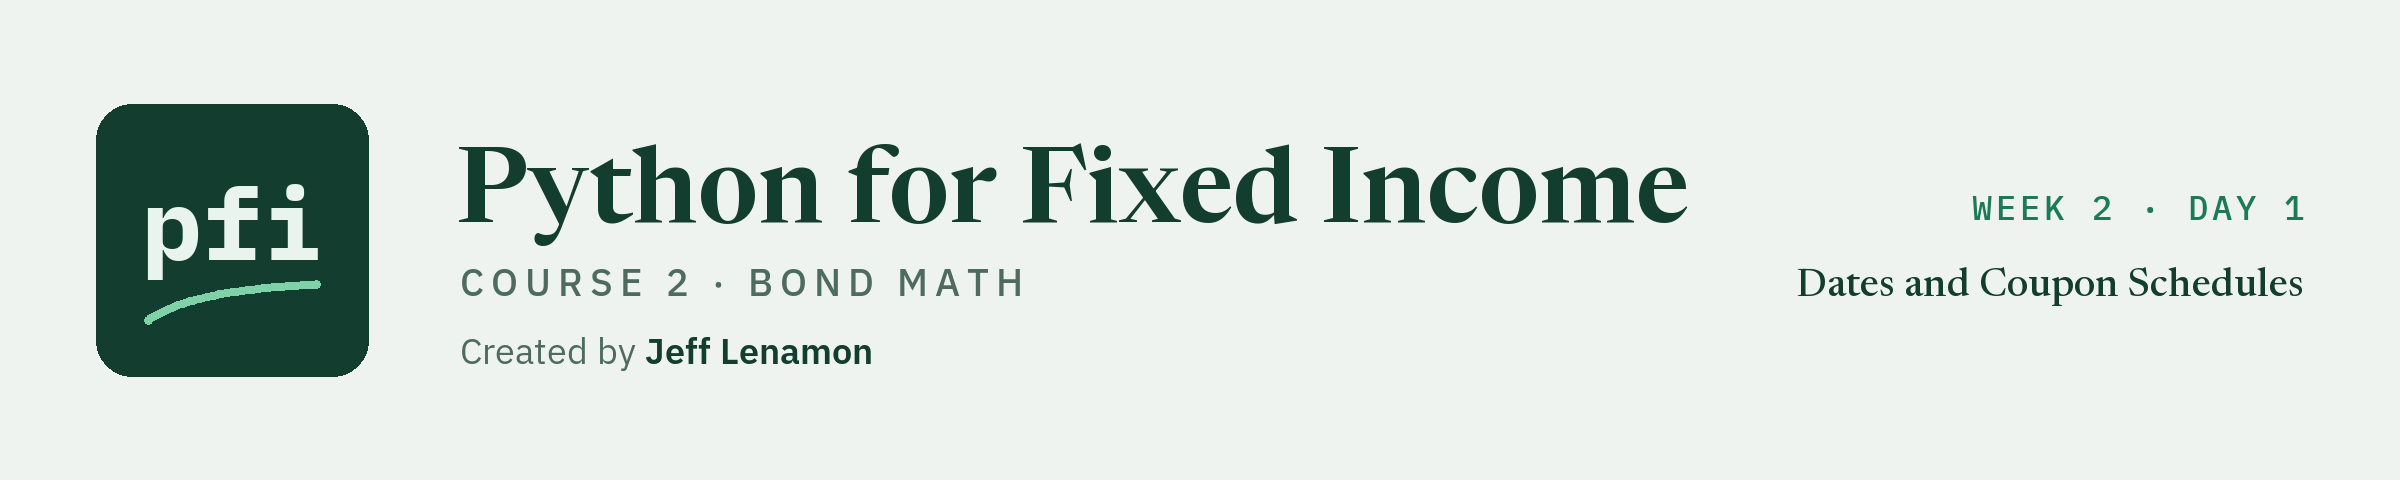

# Dates and Coupon Schedules

Week 2, Day 1. Week 2 settles bonds between coupons, so first the dates: Python's dates, adding months, counting coupon dates back from maturity with Excel's month-end rule, and the previous coupon, the next coupon, and the coupons left, checked against Excel's COUPPCD, COUPNCD, and COUPNUM.

> This course is educational content created in a personal capacity. Nothing here is investment advice or a recommendation to buy or sell any security. All portfolio data is synthetic.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/lenamonj/python-fixed-income/blob/main/course2_bond_math/week2/day1/06_dates_and_coupon_schedules.ipynb)

Week 1 kept one thing simple on purpose: every bond settled on a coupon date, 30 September 2026, the day it was issued. Nothing had accrued, clean price equalled dirty price, and the years left were a whole number of half-years.

Bonds do not trade only on coupon dates. **Week 2 settles the same four bonds on Monday 30 November 2026**, two months after issue, between two coupons. On that date three questions come before any price:

1. When was the **previous coupon** date, the date interest starts to accrue from?
2. When is the **next coupon**?
3. How many **coupons are left** to be paid?

Days 7 to 9 build accrued interest, the price between coupons, and duration on these three answers. Today finds them.

Today you will:

1. Make dates in Python with `datetime.date`, count the days between them with `timedelta`, and compare them, and see the serial numbers Excel keeps under its dates.
2. See why adding months is not the same as adding days.
3. Add `add_months` to your module, a function that moves a date by whole months and handles short months.
4. Count coupon dates back from maturity, and see why each one is counted from maturity itself.
5. Apply Excel's month-end rule.
6. Add `coupon_dates`, which returns the previous coupon, the next coupon, and every coupon left, checked against Excel's `COUPPCD`, `COUPNCD`, and `COUPNUM`.
7. Work with date columns in pandas, and meet two bonds where two systems disagree.

The issuers are invented, and so is every number. Nothing here says a bond or an issuer is good or bad.

The setup cell is the same as last week's. Then the next cell writes `bondmath.py` and `test_bondmath.py` as they stood at the end of day 5.

Q. Set up today's work folder and copy the Excel reference files into it.

In [1]:
# modules that come with Python: folders and files, the temp folder, running programs, reloading a module
import importlib
import os
import shutil
import subprocess
import sys
import tempfile
import urllib.request
from pathlib import Path

import pandas as pd

# pytest runs the tests. A Colab runtime may not have it.
try:
    import pytest
except ImportError:
    raise RuntimeError("pytest is not installed. Run  !pip install pytest  in a new cell, then run this cell again.") from None

# remember the notebook's own folder, so that running this cell again starts from the same place
if "notebook_folder" not in globals():
    notebook_folder = Path.cwd()

# 1. find the course data before moving: the repo's data folder on your machine, GitHub in Colab
RAW_DATA = "https://raw.githubusercontent.com/lenamonj/python-fixed-income/main/data/"
local_data = (notebook_folder / ".." / ".." / ".." / "data").resolve()
on_github = not (local_data / "bondmath_excel_reference.csv").exists()
data_folder = RAW_DATA if on_github else str(local_data) + os.sep

# 2. a fresh work folder for today, in the system temp folder, outside the course repo
work = Path(tempfile.mkdtemp(prefix="pfi_course2_06_"))
os.chdir(work)

# 3. copy the two Excel reference files into the work folder
for name in ["bondmath_excel_reference.csv", "bondmath_excel_reference_tvm.csv"]:
    if on_github:
        urllib.request.urlretrieve(RAW_DATA + name, work / name)
    else:
        shutil.copy(local_data / name, work / name)

# print the folder's name only: its full path would show your user name
print(f"Work folder: {work.name}, in your temp folder")
print(f"Reference files copied from: {'GitHub' if on_github else 'the data folder of the course repo'}")
print(f"pytest version: {pytest.__version__}")

Work folder: pfi_course2_06_k3xvhu7b, in your temp folder
Reference files copied from: the data folder of the course repo
pytest version: 9.1.1


Q. Write `bondmath.py` and `test_bondmath.py` as they stand at the start of today: the reference version at the end of the last notebook.

In [2]:
%%writefile bondmath.py
"""bondmath: bond math for fixed-rate bullet bonds, checked against Excel.

Written day by day in Python for Fixed Income, Course 2: Bond Math.

Units, the same in every function:
- coupon_pct and yield_pct are annual rates in percent: 7.0 means 7 percent. Excel takes decimals (0.07).
- Prices and accrued interest are per 100 of face.
- Durations are in years, convexity in years squared, spreads in basis points.
- frequency is the number of coupons (or compounding periods) a year: 1, 2, or 4.
- basis is the day count: "30/360" (Excel basis 0) or "ACT/ACT" (Excel basis 1).
- Dates are datetime.date values.
"""
import calendar  # month lengths, used from week 2
from datetime import date  # calendar dates, used from week 2


def future_value(amount: float, rate_pct: float, years: float, frequency: int = 2) -> float:
    """Grow an amount at an annual rate compounded `frequency` times a year.

    Units: amount in dollars (or per 100 of face), rate_pct in percent, years in years.
    Convention: periodic compounding, amount x (1 + rate / frequency) ** (frequency x years).
    Excel: =FV(rate_pct/100/frequency, frequency*years, 0, -amount)
    """
    # stop on a frequency the course does not use
    if frequency not in (1, 2, 4):
        raise ValueError(f"frequency must be 1, 2, or 4, not {frequency}")
    # the rate for one period, as a decimal
    period_rate = rate_pct / 100 / frequency
    # the number of compounding periods
    periods = frequency * years
    # grow the amount over every period
    return amount * (1 + period_rate) ** periods


def present_value(amount: float, rate_pct: float, years: float, frequency: int = 2) -> float:
    """Discount an amount due in `years` at an annual rate compounded `frequency` times a year.

    Units: amount in dollars (or per 100 of face), rate_pct in percent, years in years.
    Convention: periodic compounding, amount / (1 + rate / frequency) ** (frequency x years).
    Returns a positive number for a positive amount. Excel's PV returns the same number with a
    minus sign: =-PV(rate_pct/100/frequency, frequency*years, 0, amount)
    """
    # stop on a frequency the course does not use
    if frequency not in (1, 2, 4):
        raise ValueError(f"frequency must be 1, 2, or 4, not {frequency}")
    # the rate for one period, as a decimal
    period_rate = rate_pct / 100 / frequency
    # the number of compounding periods
    periods = frequency * years
    # discount the amount over every period
    return amount / (1 + period_rate) ** periods


def cash_flows(coupon_pct: float, years: float, frequency: int = 2) -> list[tuple[float, float]]:
    """The cash flows of a bullet bond bought on a coupon date.

    Units: coupon_pct in percent of face a year, years in years. Each cash flow is per 100 of face.
    Convention: one coupon of coupon_pct / frequency every 1 / frequency years, and 100 back with
    the last coupon. Returns a list of (time in years, cash flow) pairs, earliest first.
    Raises ValueError unless years x frequency is a whole number of periods.
    """
    # stop on a frequency the course does not use
    if frequency not in (1, 2, 4):
        raise ValueError(f"frequency must be 1, 2, or 4, not {frequency}")
    # count the coupon periods and check they are whole
    periods = years * frequency
    if periods <= 0 or abs(periods - round(periods)) > 1e-9:
        raise ValueError(f"{years} years is not a whole number of periods at frequency {frequency}")
    periods = round(periods)
    # each coupon is the annual coupon split into equal parts
    coupon = coupon_pct / frequency
    flows = []
    for k in range(1, periods + 1):
        # the time of payment k, in years
        time_years = k / frequency
        # the last payment also returns the face of 100
        amount = coupon + 100 if k == periods else coupon
        flows.append((time_years, amount))
    return flows


def price_from_yield(coupon_pct: float, yield_pct: float, years: float, frequency: int = 2) -> float:
    """Price of a bullet bond on a coupon date, from its yield.

    Units: coupon_pct and yield_pct in percent a year, years in years, price per 100 of face.
    Convention: each cash flow is discounted at yield_pct compounded `frequency` times a year.
    On a coupon date there is no accrued interest, so this is both the clean and the dirty price.
    Excel: =-PV(yield_pct/100/frequency, frequency*years, coupon_pct/frequency, 100)
    """
    # the yield for one period, as a decimal
    period_yield = yield_pct / 100 / frequency
    price = 0.0
    for time_years, amount in cash_flows(coupon_pct, years, frequency):
        # discount each cash flow by one factor per period until it is paid
        price += amount / (1 + period_yield) ** (time_years * frequency)
    return price


def convert_yield(yield_pct: float, from_frequency: int, to_frequency: int) -> float:
    """The same yield restated at another compounding frequency.

    Units: yield_pct in percent a year; the result is in percent a year.
    Convention: both rates grow 100 to the same amount in one year.
    Excel: convert_yield(y, f, 1) is =EFFECT(y/100, f)*100, and convert_yield(y, 1, f) is =NOMINAL(y/100, f)*100.
    """
    # stop on a frequency the course does not use
    for frequency in (from_frequency, to_frequency):
        if frequency not in (1, 2, 4):
            raise ValueError(f"frequency must be 1, 2, or 4, not {frequency}")
    # how much 1 grows to in one year at the original frequency
    growth_one_year = (1 + yield_pct / 100 / from_frequency) ** from_frequency
    # the rate per period at the new frequency that gives the same growth
    period_rate = growth_one_year ** (1 / to_frequency) - 1
    # back to an annual rate in percent
    return period_rate * to_frequency * 100


def yield_from_price(coupon_pct: float, price: float, years: float, frequency: int = 2) -> float:
    """Yield of a bullet bond on a coupon date, from its price, by bisection.

    Units: coupon_pct in percent a year, price per 100 of face, years in years; the result is in percent.
    Convention: the yield, compounded `frequency` times a year, at which price_from_yield equals price.
    The search runs between -5 and 100 percent and stops when the bracket is narrower than 1e-10 percent.
    Raises ValueError if the price is outside the prices at those two yields.
    Excel: =RATE(frequency*years, coupon_pct/frequency, -price, 100)*frequency, then x 100.
    """
    # the bracket: price falls as yield rises, so the low yield gives the high price
    low_pct, high_pct = -5.0, 100.0
    highest_price = price_from_yield(coupon_pct, low_pct, years, frequency)
    lowest_price = price_from_yield(coupon_pct, high_pct, years, frequency)
    if not lowest_price <= price <= highest_price:
        raise ValueError(f"price {price} is outside {lowest_price:.6f} to {highest_price:.6f}, "
                         f"the prices at yields of {high_pct} and {low_pct} percent")
    # halve the bracket until it is narrow enough
    while high_pct - low_pct > 1e-10:
        mid_pct = (low_pct + high_pct) / 2
        if price_from_yield(coupon_pct, mid_pct, years, frequency) > price:
            # price too high at mid, so the yield is above mid
            low_pct = mid_pct
        else:
            # price too low (or equal) at mid, so the yield is at or below mid
            high_pct = mid_pct
    # the middle of the final bracket
    return (low_pct + high_pct) / 2

Writing bondmath.py


In [3]:
%%writefile test_bondmath.py
"""Tests for bondmath.py.

Every expected value comes from Excel: the two reference CSV files in this folder, or a small hand
table whose values those files confirm. Run from this folder with:  python -m pytest
"""
import csv
import math  # used from week 3
from datetime import date  # used from week 2
from pathlib import Path

import pytest

import bondmath

# the reference files sit in the same folder as this test file
HERE = Path(__file__).parent


def read_rows(file_name: str) -> list[dict]:
    """Read a reference CSV from this folder: one dict per row, every value a string."""
    with open(HERE / file_name, newline="", encoding="utf-8") as f:
        return list(csv.DictReader(f))


TVM = read_rows("bondmath_excel_reference_tvm.csv")


def tvm_rows(function: str) -> list[dict]:
    """The week 1 reference rows for one Excel function, for example "FV"."""
    rows = [row for row in TVM if row["function"] == function]
    assert rows, f"no {function} rows in the reference file"
    return rows


def test_future_value_matches_excel_fv():
    for row in tvm_rows("FV"):
        # the inputs, in course units
        amount, rate_pct = float(row["amount"]), float(row["rate_pct"])
        years, frequency = float(row["years"]), int(row["frequency"])
        result = bondmath.future_value(amount, rate_pct, years, frequency)
        # Excel's FV, with the amount entered as -amount, is positive
        assert result == pytest.approx(float(row["excel_value"]), abs=1e-6), row["case_id"]


def test_present_value_matches_excel_pv():
    for row in tvm_rows("PV"):
        amount, rate_pct = float(row["amount"]), float(row["rate_pct"])
        years, frequency = float(row["years"]), int(row["frequency"])
        result = bondmath.present_value(amount, rate_pct, years, frequency)
        # Excel's PV of a positive amount is negative (money paid now), so compare with minus the Excel value
        assert result == pytest.approx(-float(row["excel_value"]), abs=1e-6), row["case_id"]


def test_present_value_undoes_future_value():
    for frequency in (1, 2, 4):
        # grow 100 for 3 years at 5 percent, then discount it back
        grown = bondmath.future_value(100, 5.0, 3, frequency)
        assert bondmath.present_value(grown, 5.0, 3, frequency) == pytest.approx(100, abs=1e-9)


REFERENCE = read_rows("bondmath_excel_reference.csv")


def test_cash_flows_count_and_final_flow():
    flows = bondmath.cash_flows(6.0, 5, 2)
    # 5 years of half-year coupons is 10 cash flows
    assert len(flows) == 10
    # the first is a 3.00 coupon after half a year, the last is the coupon plus the face at 5 years
    assert flows[0] == pytest.approx((0.5, 3.0))
    assert flows[-1] == pytest.approx((5.0, 103.0))


def test_cash_flows_raises_on_part_periods():
    # 2.3 years is not a whole number of half years, so cash_flows must stop with a ValueError
    try:
        bondmath.cash_flows(6.0, 2.3, 2)
    except ValueError:
        return
    assert False, "cash_flows accepted 2.3 years at frequency 2"


def test_price_from_yield_matches_excel():
    # Excel's -PV with a coupon: a bond priced on a coupon date
    for row in tvm_rows("PV_BOND"):
        result = bondmath.price_from_yield(float(row["coupon_pct"]), float(row["rate_pct"]),
                                           float(row["years"]), int(row["frequency"]))
        assert result == pytest.approx(float(row["excel_value"]), abs=1e-6), row["case_id"]
    # Excel's PRICE on the rows that settle on a coupon date (no days accrued)
    coupon_date_rows = [row for row in REFERENCE if row["coupdaybs"] == "0"]
    assert coupon_date_rows, "no coupon-date rows in the reference file"
    for row in coupon_date_rows:
        frequency = int(row["frequency"])
        years = int(row["coupnum"]) / frequency
        result = bondmath.price_from_yield(float(row["coupon_pct"]), float(row["yield_pct"]), years, frequency)
        assert result == pytest.approx(float(row["price"]), abs=1e-6), row["case_id"]


def test_convert_yield_matches_excel_effect_and_nominal():
    # EFFECT restates a rate compounded `frequency` times a year as an annually compounded rate
    for row in tvm_rows("EFFECT"):
        result = bondmath.convert_yield(float(row["rate_pct"]), int(row["frequency"]), 1)
        # Excel returns a decimal, bondmath a percent
        assert result == pytest.approx(float(row["excel_value"]) * 100, abs=1e-9), row["case_id"]
    # NOMINAL goes the other way: from annual compounding to `frequency` times a year
    for row in tvm_rows("NOMINAL"):
        result = bondmath.convert_yield(float(row["rate_pct"]), 1, int(row["frequency"]))
        assert result == pytest.approx(float(row["excel_value"]) * 100, abs=1e-9), row["case_id"]


def test_convert_yield_round_trip():
    # semiannual to quarterly and back gives the yield we started with
    quarterly = bondmath.convert_yield(6.0, 2, 4)
    assert bondmath.convert_yield(quarterly, 4, 2) == pytest.approx(6.0, abs=1e-12)


def test_yield_from_price_matches_excel():
    # Excel's RATE, times the frequency, is the annual yield as a decimal
    for row in tvm_rows("RATE"):
        result = bondmath.yield_from_price(float(row["coupon_pct"]), float(row["price"]),
                                           float(row["years"]), int(row["frequency"]))
        assert result == pytest.approx(float(row["excel_value"]) * 100, abs=1e-6), row["case_id"]
    # Excel's YIELD on the coupon-date rows, already in percent in the reference file
    for row in REFERENCE:
        if row["coupdaybs"] != "0":
            continue
        frequency = int(row["frequency"])
        years = int(row["coupnum"]) / frequency
        result = bondmath.yield_from_price(float(row["coupon_pct"]), float(row["price"]), years, frequency)
        assert result == pytest.approx(float(row["yield_pct_from_price"]), abs=1e-6), row["case_id"]


def test_yield_raises_outside_bracket():
    # no yield between -5 and 100 percent gives a price of 1,000 or of 0.01
    with pytest.raises(ValueError):
        bondmath.yield_from_price(6.0, 1000.0, 5, 2)
    with pytest.raises(ValueError):
        bondmath.yield_from_price(6.0, 0.01, 5, 2)


def test_yield_round_trip():
    # price a bond from a yield, then solve the yield back from that price
    bond_price = bondmath.price_from_yield(5.25, 6.1, 7, 2)
    assert bondmath.yield_from_price(5.25, bond_price, 7, 2) == pytest.approx(6.1, abs=1e-8)


def test_par_bond_prices_at_100():
    # a coupon equal to the yield prices at 100 for every frequency and term
    for frequency in (1, 2, 4):
        for years in (1, 2, 5, 10, 30):
            assert bondmath.price_from_yield(5.5, 5.5, years, frequency) == pytest.approx(100, abs=1e-9)


def test_price_falls_as_yield_rises():
    # price a 10-year 6 percent bond at yields from 2 to 12 percent
    prices = [bondmath.price_from_yield(6.0, yield_pct, 10, 2) for yield_pct in (2, 4, 6, 8, 10, 12)]
    # every price is below the one before it
    for earlier, later in zip(prices, prices[1:]):
        assert later < earlier

Writing test_bondmath.py


Q. Import the module.

In [4]:
# Python finds a module in the folders listed in sys.path. Put the work folder first.
sys.path.insert(0, str(work))
import bondmath

# reload reads the file again, so that running this cell after a change picks up the change
importlib.reload(bondmath)

# the functions defined in the module itself, not the ones it imports
functions = [name for name, obj in vars(bondmath).items() if callable(obj) and getattr(obj, "__module__", "") == "bondmath"]
print(f"bondmath functions: {functions}")

bondmath functions: ['future_value', 'present_value', 'cash_flows', 'price_from_yield', 'convert_yield', 'yield_from_price']


* The two files exactly as day 5 left them: six functions and thirteen tests. By the end of today there will be eight functions.

Record the starting point in Git first, as every day since day 2.

Q. Make the work folder a repository and commit the start-of-day files.

In [5]:
# stop here, with the steps to install it, if Git is not on this machine
if shutil.which("git") is None:
    raise RuntimeError("Git is not installed. Install Git for Windows from https://git-scm.com/downloads "
                       "(or run  winget install --id Git.Git  where your firm allows it), restart VS Code, "
                       "and run this cell again. Colab has Git already.")

# -C "{work}" points every Git command at the work folder, whatever folder the notebook is in
!git -C "{work}" --version
# make the work folder a repository
!git -C "{work}" init -q -b main
# settings for this repository only: a course name, a reserved example email, line endings left as they are,
# and no commit signing, so a signing setup on your machine does not ask for a key here
!git -C "{work}" config user.name "Course Student"
!git -C "{work}" config user.email "student@example.com"
!git -C "{work}" config core.autocrlf false
!git -C "{work}" config commit.gpgsign false

git version 2.50.1.windows.1


Q. Is Git working in the work folder, and only there?

In [6]:
# the guard: Git must report the work folder as the top of this repository, or the notebook stops
top = subprocess.run(["git", "-C", str(work), "rev-parse", "--show-toplevel"],
                     capture_output=True, text=True, check=True).stdout.strip()
assert os.path.samefile(top, work), "Git is not working in the work folder. Stop, and run the setup cell again."
print(f"Git is working in {work.name} and nowhere else")

Git is working in pfi_course2_06_k3xvhu7b and nowhere else


In [7]:
# choose the two files, commit them quietly, and show the history
!git -C "{work}" add bondmath.py test_bondmath.py
!git -C "{work}" commit -q -m "Start of day 6: bondmath.py and test_bondmath.py as day 5 left them"
!git -C "{work}" log --oneline

3774f8a Start of day 6: bondmath.py and test_bondmath.py as day 5 left them


* One commit, the start of day 6. Its hash changes on every run.

Q. Type in the four bonds.

In [8]:
bonds = pd.DataFrame({
    "cusip": ['99001BZA7', '99002CZA4', '99003DZA1', '99004EZA8'],
    "issuer": ['Quorvane Energy', 'Dunmarrow Rail', 'Pellwick Paper', 'Halvering Foods'],
    "ticker": ['QVNE', 'DNMR', 'PLWK', 'HLVF'],
    "rating": ['BBB', 'BB+', 'A-', 'B+'],
    "coupon_pct": [5.25, 6.125, 4.75, 7.5],
    # maturity as text for now: section 6.1 turns it into dates
    "maturity": ['2031-09-30', '2033-09-30', '2029-09-30', '2036-09-30'],
})

bonds

,cusip,issuer,ticker,rating,coupon_pct,maturity
0,99001BZA7,Quorvane Energy,QVNE,BBB,5.250,2031-09-30
1,99002CZA4,Dunmarrow Rail,DNMR,BB+,6.125,2033-09-30
2,99003DZA1,Pellwick Paper,PLWK,A-,4.750,2029-09-30
3,99004EZA8,Halvering Foods,HLVF,B+,7.500,2036-09-30


* The same four bonds as week 1, with the same coupons and maturities. Each matures on 30 September, and that date will matter in section 6.5.
* The maturities are text for now: `"2031-09-30"` is a string of ten characters, not a date. Python cannot count days between two strings.

## 6.1 `datetime.date`, `timedelta`, and Comparing Dates

Python's standard library has a module for dates, `datetime`. Its `date` type holds a year, a month, and a day, and nothing else: no time of day, no time zone. That is exactly what a settlement date or a maturity date is. `bondmath.py` has imported it since day 1, waiting for week 2.

Q. Make the week 2 settlement date and look inside it.

In [9]:
from datetime import date, timedelta

# date(year, month, day): 30 November 2026
settlement = date(2026, 11, 30)

print(f"settlement: {settlement}")
print(f"year {settlement.year}, month {settlement.month}, day {settlement.day}")
# strftime formats a date as text: %A is the name of the weekday
print(f"weekday: {settlement.strftime('%A')}")

settlement: 2026-11-30
year 2026, month 11, day 30
weekday: Monday


* A `date` prints as year-month-day, the ISO format the course's data files use. `.year`, `.month`, and `.day` are whole numbers.
* 30 November 2026 is a Monday, a business day. This course does not adjust dates for weekends or holidays.

Q. How many days from the issue date, 30 September 2026, to settlement?

In [10]:
issue = date(2026, 9, 30)

# one date minus another is a timedelta: a length of time
gap = settlement - issue
print(f"{type(gap).__name__}: {gap}")
print(f"days from issue to settlement: {gap.days}")

timedelta: 61 days, 0:00:00
days from issue to settlement: 61


* 61 actual days: the 31 days of October and the 30 of November. A `timedelta` is a length of time; `.days` is that length in whole days.
* These are actual calendar days. Day 7 shows that a 30/360 bond counts the same stretch as 60 days, a different answer to a different question.

Q. Add a day to a date, and compare two dates.

In [11]:
# a date plus a timedelta is another date
print(f"the day after settlement: {settlement + timedelta(days=1)}")

# date.fromisoformat turns year-month-day text into a date
quorvane_maturity = date.fromisoformat("2031-09-30")
# dates compare in calendar order: earlier is smaller
print(f"settlement before maturity: {settlement < quorvane_maturity}")
print(f"latest of the two: {max(settlement, quorvane_maturity)}")

the day after settlement: 2026-12-01
settlement before maturity: True
latest of the two: 2031-09-30


* `<`, `>`, `max`, and `sorted` all work on dates, in calendar order. A string comparison would also put these two in order, but only because both are written year first with two-digit months; dates do not depend on that.

Q. Turn every maturity in the table into a date, and check that each bond matures after settlement.

In [12]:
bonds["maturity_date"] = [date.fromisoformat(text) for text in bonds["maturity"]]

# a bond that matured before settlement cannot settle: stop here if one did
assert all(settlement < maturity for maturity in bonds["maturity_date"]), "a bond matures before settlement"
bonds[["issuer", "maturity", "maturity_date"]]

,issuer,maturity,maturity_date
0,Quorvane Energy,2031-09-30,2031-09-30
1,Dunmarrow Rail,2033-09-30,2033-09-30
2,Pellwick Paper,2029-09-30,2029-09-30
3,Halvering Foods,2036-09-30,2036-09-30


* The two columns print alike, but `maturity_date` holds `date` values that can be subtracted and compared. The check passed: all four mature after 30 November 2026.

**Excel side by side: date serial numbers.** Excel keeps a date as a number, the count of days in its own calendar, and shows it in a date format. Tested in Excel: type `=DATE(2026,11,30)` in A1 and Excel formats the cell as a date. Change the cell's number format to General (Home, Number Format, General) and it shows 46356. `=DATE(2026,9,30)` is 46295. So subtracting two dates is subtracting two numbers: `=DATE(2026,11,30)-DATE(2026,9,30)` returns 61, and `=TEXT(DATE(2026,11,30),"dddd")` returns `Monday`.

Q. What is Excel's serial number for the settlement date, computed in Python?

In [13]:
# Excel's serial number is the count of days from 30 December 1899, for every date from 1 March 1900 on
excel_serial = (settlement - date(1899, 12, 30)).days
print(f"Excel's serial number for {settlement}: {excel_serial}")

Excel's serial number for 2026-11-30: 46356


* 46356, the number Excel shows under General. Why 30 December 1899, and why only from 1 March 1900? The story is in the next box.

> **Story: the day that never was.** Excel counts 1 January 1900 as day 1. It also treats 1900 as a leap year, which it was not: in Excel, `=DATE(1900,2,28)` is 59, `=DATE(1900,2,29)` is 60, and `=DATE(1900,3,1)` is 61 (tested). Microsoft's own documentation explains why: when Lotus 1-2-3 was first released it assumed 1900 was a leap year, and Excel kept the same serial date system for compatibility with Lotus 1-2-3, so worksheets could move between the two programs. Correcting it now would shift almost every date in existing worksheets by a day. Source: Microsoft Learn, "Excel incorrectly assumes that the year 1900 is a leap year", https://learn.microsoft.com/en-us/troubleshoot/microsoft-365-apps/excel/wrongly-assumes-1900-is-leap-year (read 2026-10-04). That extra day is why the Python formula counts from 30 December 1899, and why it matches Excel only from 1 March 1900. No bond in this course is that old.

Q. Does Python agree that 29 February 1900 existed?

In [14]:
# 1900 is divisible by 100 and not by 400, so it was not a leap year
date(1900, 2, 29)

ValueError: day is out of range for month

* `ValueError: day is out of range for month`. Python's calendar has no 29 February 1900. A `date` refuses any day that does not exist, and that refusal matters in the next section.

## 6.2 Adding Months Is Not Adding Days

A semiannual bond pays every six months, not every 182 days. Months have 28, 29, 30, or 31 days, so six months is not a fixed number of days.

Q. Add 182 days to the issue date, then 182 more. Do you land on the coupon dates?

In [15]:
first = issue + timedelta(days=182)
second = first + timedelta(days=182)

print(f"{issue} + 182 days = {first}")
print(f"{first} + 182 days = {second}")

2026-09-30 + 182 days = 2027-03-31
2027-03-31 + 182 days = 2027-09-29


* The first step lands on 2027-03-31, which happens to be a month end. The second lands on 2027-09-29: not the 30 September a September coupon falls on. Six months from 31 March to 30 September is 183 days. **A fixed number of days drifts.**

Q. Then change the month number instead: six months after September is month 9 + 6.

In [16]:
# month 15 does not exist: the year has to roll over
date(2026, 9 + 6, 30)

ValueError: month must be in 1..12

* `ValueError: month must be in 1..12`. Moving the month past December has to carry into the year.

Q. And 31 August moved six months on, to February?

In [17]:
# February has no 31st
date(2027, 2, 31)

ValueError: day is out of range for month

* `ValueError: day is out of range for month`. When the new month is shorter, the day has to come down to that month's last day.

Q. How long is each month? The standard library's `calendar` module knows.

In [18]:
import calendar

# monthrange(year, month) returns the weekday of the 1st and the number of days in the month
for year, month in [(2027, 2), (2028, 2), (2027, 3), (2027, 4)]:
    days_in_month = calendar.monthrange(year, month)[1]
    print(f"{year}-{month:02d}: {days_in_month} days")

2027-02: 28 days
2028-02: 29 days
2027-03: 31 days
2027-04: 30 days


* February 2027 has 28 days and February 2028, a leap year, 29. `calendar.monthrange(...)[1]` is the number of days in any month, and the next function uses it.
* So moving a date by months needs two things: carry the months into the year, and bring the day down to the length of a short month. That is the job of `add_months`.

## 6.3 `add_months` and Short Months

The trick for carrying months into years is to number the months in one long count: year times 12, plus the month counted from 0. Add the months to that count, then split it back into a year and a month with `divmod`, which returns the whole part and the remainder of a division at once.

Q. Six months before 31 August 2031, in that count.

In [19]:
# months counted from year 0: January 2031 is 2031 * 12 + 0, August 2031 is 2031 * 12 + 7
month_index = 2031 * 12 + (8 - 1) - 6

# divmod gives the year, and the month counted from 0
year, month_zero_based = divmod(month_index, 12)
print(f"year {year}, month {month_zero_based + 1}")

year 2031, month 2


* February 2031. February 2031 has 28 days, so the 31st comes down to the 28th.

Q. Add `add_months` to the end of `bondmath.py`. Read it before you run the cell.

In [20]:
%%writefile -a bondmath.py


def add_months(d: date, months: int) -> date:
    """Move a date by whole months, keeping the day of the month where the month allows it.

    Units: d is a date, months a whole number (negative moves back).
    Convention: the day is clamped to the length of the new month, so 31 August minus 6 months is
    28 February (29 February in a leap year). Excel: =EDATE(d, months)
    """
    # count months from year 0 so the year and month come out of one division
    month_index = d.year * 12 + (d.month - 1) + months
    year, month_zero_based = divmod(month_index, 12)
    month = month_zero_based + 1
    # the number of days in the new month
    days_in_month = calendar.monthrange(year, month)[1]
    # keep the day, or use the last day of a shorter month
    return date(year, month, min(d.day, days_in_month))

Appending to bondmath.py


* `Appending to bondmath.py`. The docstring states the units, the clamping convention with an example, and the Excel function, `EDATE`.
* Three steps in the code: the month count and `divmod`, the length of the new month from `calendar.monthrange`, and `min` to keep the day or use the month's last day.

Q. Reload the module and try it on the cases from section 6.2.

In [21]:
importlib.reload(bondmath)

cases = [(date(2031, 8, 31), -6), (date(2032, 8, 31), -6), (date(2027, 1, 31), 1), (date(2026, 11, 15), 3),
         (date(2031, 9, 30), -6)]
for d, months in cases:
    print(f"{d} moved {months:+d} months: {bondmath.add_months(d, months)}")

2031-08-31 moved -6 months: 2031-02-28


2032-08-31 moved -6 months: 2032-02-29
2027-01-31 moved +1 months: 2027-02-28
2026-11-15 moved +3 months: 2027-02-15
2031-09-30 moved -6 months: 2031-03-30


* 31 August moves back to 28 February in 2031 and to 29 February in the leap year 2032. 31 January moves on to 28 February. 15 November moves across the year end to 15 February, the day kept because every month has a 15th.
* The last line: 30 September moved back six months is **30 March**. Hold on to that for section 6.5.

**Excel side by side: `EDATE`.** Excel's function for moving a date by whole months, tested in Excel. `=EDATE(DATE(2031,8,31),-6)` returns 28 February 2031 (as a serial number; give the cell a date format to see it as a date). `=EDATE(DATE(2032,8,31),-6)` returns 29 February 2032, `=EDATE(DATE(2027,1,31),1)` returns 28 February 2027, `=EDATE(DATE(2026,11,15),3)` returns 15 February 2027, and `=EDATE(DATE(2031,9,30),-6)` returns 30 March 2031. All five equal `add_months`.

Q. Add the first test.

In [22]:
%%writefile -a test_bondmath.py


def test_add_months_clamps_to_month_end():
    # 31 August back 6 months: 28 February, or 29 February in a leap year
    assert bondmath.add_months(date(2031, 8, 31), -6) == date(2031, 2, 28)
    assert bondmath.add_months(date(2032, 8, 31), -6) == date(2032, 2, 29)
    # 31 January forward 1 month
    assert bondmath.add_months(date(2027, 1, 31), 1) == date(2027, 2, 28)
    # a day every month has is kept, across a year end
    assert bondmath.add_months(date(2026, 11, 15), 3) == date(2027, 2, 15)

Appending to test_bondmath.py


* Four cases: two short Februaries, a month forward from a 31st, and a step across a year end. Each value is what Excel's `EDATE` returned for the same date and months.

## 6.4 Counting Coupon Dates Back from Maturity

A bond's coupon schedule is fixed by its maturity date. A semiannual bond pays on maturity and every six months before it. So the schedule is found by counting **back** from maturity: maturity, maturity minus 6 months, minus 12, and so on, until a date on or before settlement.

Q. Count Quorvane's last four coupon dates back from maturity with `add_months`.

In [23]:
for k in range(4):
    # coupon k: maturity moved back k times 6 months
    print(f"k = {k}: {bondmath.add_months(quorvane_maturity, -6 * k)}")

k = 0: 2031-09-30
k = 1: 2031-03-30
k = 2: 2030-09-30
k = 3: 2030-03-30


* 30 September and 30 March, alternating. Keep that in mind: section 6.5 checks it against Excel.

Each date above is computed from maturity directly: `add_months(maturity, -6 * k)`. A shorter-looking loop would step from the previous date each time, `add_months(previous, -6)`. For many bonds the two give the same dates. Not for all of them.

Q. A bond maturing on 30 August 2031: step back from the date before, and count back from maturity, side by side.

In [24]:
august_maturity = date(2031, 8, 30)

stepped = []
previous = august_maturity
for k in range(1, 5):
    # from the date before: once February clamps the day to the 28th, the 28th carries on
    previous = bondmath.add_months(previous, -6)
    stepped.append(previous)

# from maturity itself: the 30th comes back after every February
from_maturity = [bondmath.add_months(august_maturity, -6 * k) for k in range(1, 5)]

pd.DataFrame({"k": [1, 2, 3, 4], "stepped_from_previous": stepped, "counted_from_maturity": from_maturity})

,k,stepped_from_previous,counted_from_maturity
0,1,2031-02-28,2031-02-28
1,2,2030-08-28,2030-08-30
2,3,2030-02-28,2030-02-28
3,4,2029-08-28,2029-08-30


* Both start at 28 February 2031: February has no 30th. Then they part. Stepping from 28 February gives 28 August, and the 28th sticks for every date after. Counting from maturity gives 30 August again, because each date starts from the 30th.
* **Count every coupon date from maturity, never from the date before it.** A schedule that drifts two days puts every accrual date in the wrong place.

**Excel side by side: the same drift in a sheet.** Tested in Excel: type the maturity, `=DATE(2031,8,30)`, in A1, then `=EDATE(A1,-6)` in A2 and fill it down. Each cell steps from the one above, and column A shows 2031-02-28, 2030-08-28, 2030-02-28, and so on: the drift. Put 1, 2, 3, ... in C2 down, and in B2 type `=EDATE($A$1,-6*C2)` and fill it down. The dollar signs fix A1, so every cell counts from maturity: 2031-02-28, 2030-08-30, 2030-02-28. Excel behaves exactly like Python here; the drift comes from the way the sheet is built, not from `EDATE`.

## 6.5 The Month-End Rule

Section 6.4 put Quorvane's March coupons on 30 March. Excel's reference file has the answer for Quorvane on 30 November 2026.

Q. What does Excel's `COUPNCD`, the next coupon date, say for Quorvane?

In [25]:
reference = pd.read_csv("bondmath_excel_reference.csv")

# the week 2 rows: the week 1 bonds settled on 30 November 2026, one row per bond, case_id the CUSIP
week2 = reference[reference["group"] == "week2"].set_index("case_id")
print(f"Excel's next coupon for Quorvane: {week2.loc['99001BZA7', 'coupncd']}")
# the next coupon is 9 steps of 6 months back from maturity
print(f"add_months from maturity:         {bondmath.add_months(quorvane_maturity, -6 * 9)}")

Excel's next coupon for Quorvane: 2027-03-31
add_months from maturity:         2027-03-30


* Excel says **31 March 2027**, not 30 March. Quorvane matures on 30 September, the last day of September, and Excel reads that as "pays on the last day of the month". Its March coupon goes on the last day of March.

This is the **month-end rule**: if a bond matures on the last day of its month, every coupon date is the last day of its month. Otherwise the day of the month is kept, and comes down to the last day of a short month, as `add_months` does. The rule was tested on every row of the reference file and on 2,508 further cases run through Excel (see the course's Excel behaviour table).

Q. Is a date the last day of its month?

In [26]:
for d in [quorvane_maturity, august_maturity, date(2031, 2, 28), date(2032, 2, 28)]:
    # the last day of the month: the day equals the number of days in that month
    is_month_end = d.day == calendar.monthrange(d.year, d.month)[1]
    print(f"{d}: month end {is_month_end}")

2031-09-30: month end True
2031-08-30: month end False
2031-02-28: month end True
2032-02-28: month end False


* 30 September is a month end; 30 August is not. 28 February is a month end in 2031 and not in the leap year 2032. Section 6.7 meets two bonds where that difference matters.

**Excel side by side: `EOMONTH`.** `EOMONTH(start_date, months)` moves a date by whole months and returns the last day of that month. Tested in Excel: `=EOMONTH(DATE(2031,9,30),-6)` returns 31 March 2031, where `=EDATE(DATE(2031,9,30),-6)` returned 30 March. `=EOMONTH(DATE(2031,9,30),-12)` returns 30 September 2030. So for a month-end maturity, `EOMONTH` counts the coupon dates the way `COUPNCD` places them.

Q. Add `coupon_dates` to the end of `bondmath.py`. Read it before you run the cell.

In [27]:
%%writefile -a bondmath.py


def coupon_dates(settlement: date, maturity: date, frequency: int = 2) -> list[date]:
    """The previous coupon date, then every coupon date left through maturity.

    Units: dates. Convention: coupon dates are counted back from maturity in steps of 12 / frequency
    months, each one computed from maturity directly, so a 31st never drifts to the 28th. If maturity
    is the last day of its month, every coupon date is the last day of its month (Excel's rule).
    The previous coupon date is the last one on or before settlement.
    So [0] is Excel's COUPPCD, [1] is COUPNCD, and len - 1 is COUPNUM.
    """
    # stop on bad input
    if frequency not in (1, 2, 4):
        raise ValueError(f"frequency must be 1, 2, or 4, not {frequency}")
    if settlement >= maturity:
        raise ValueError(f"settlement {settlement} must be before maturity {maturity}")
    # months between coupons
    step_months = 12 // frequency
    # does the bond mature on the last day of a month?
    month_end = maturity.day == calendar.monthrange(maturity.year, maturity.month)[1]
    dates = []
    k = 0
    while True:
        # coupon k steps back from maturity, computed from maturity itself
        coupon_date = add_months(maturity, -k * step_months)
        if month_end:
            # the month-end rule: move to the last day of that month
            last_day = calendar.monthrange(coupon_date.year, coupon_date.month)[1]
            coupon_date = date(coupon_date.year, coupon_date.month, last_day)
        dates.append(coupon_date)
        # stop once we reach the previous coupon date
        if coupon_date <= settlement:
            break
        k += 1
    # earliest first
    dates.reverse()
    return dates

Appending to bondmath.py


* The docstring says what comes back: the previous coupon date first, then every coupon left through maturity. So `[0]` is Excel's `COUPPCD`, `[1]` is `COUPNCD`, and the number of dates after `[0]` is `COUPNUM`.
* Two checks that stop: a frequency other than 1, 2, or 4, and a settlement on or after maturity.
* The month-end flag is decided once, from maturity. Then the loop counts back from maturity with `k`, moves each date to its month end when the flag is set, and stops at the first date on or before settlement. `while True` with a `break` is a loop that decides inside itself when to stop.
* `dates.reverse()` puts the list in calendar order, earliest first.

## 6.6 Previous and Next Coupon, and Coupons Left

Q. Reload the module and print Quorvane's schedule on 30 November 2026.

In [28]:
importlib.reload(bondmath)

quorvane_dates = bondmath.coupon_dates(settlement, quorvane_maturity)
print(f"previous coupon: {quorvane_dates[0]}")
print(f"next coupon:     {quorvane_dates[1]}")
print(f"coupons left:    {len(quorvane_dates) - 1}")
print(f"the last three:  {quorvane_dates[-3:]}")

previous coupon: 2026-09-30
next coupon:     2027-03-31
coupons left:    10
the last three:  [datetime.date(2030, 9, 30), datetime.date(2031, 3, 31), datetime.date(2031, 9, 30)]


* The previous coupon date is 30 September 2026. Quorvane was issued that day and has paid no coupon yet, but its first coupon period still starts there: interest accrues from 30 September. Excel's `COUPPCD` returns the same date.
* The next coupon is 31 March 2027, the month-end rule at work, and 10 coupons are left: every 31 March and 30 September through 2031.

Q. All four bonds, against Excel's `COUPPCD`, `COUPNCD`, and `COUPNUM`.

In [29]:
rows = []
for bond in bonds.itertuples():
    dates = bondmath.coupon_dates(settlement, bond.maturity_date)
    excel = week2.loc[bond.cusip]
    rows.append({"issuer": bond.issuer, "previous": dates[0], "excel_couppcd": excel["couppcd"],
                 "next": dates[1], "excel_coupncd": excel["coupncd"],
                 "coupons_left": len(dates) - 1, "excel_coupnum": excel["coupnum"]})

schedule = pd.DataFrame(rows)
# Excel's dates are text in the file, so compare the ISO text of each date
assert (schedule["previous"].map(date.isoformat) == schedule["excel_couppcd"]).all()
assert (schedule["next"].map(date.isoformat) == schedule["excel_coupncd"]).all()
assert (schedule["coupons_left"] == schedule["excel_coupnum"]).all()
schedule

,issuer,previous,excel_couppcd,next,excel_coupncd,coupons_left,excel_coupnum
0,Quorvane Energy,2026-09-30,2026-09-30,2027-03-31,2027-03-31,10,10
1,Dunmarrow Rail,2026-09-30,2026-09-30,2027-03-31,2027-03-31,14,14
2,Pellwick Paper,2026-09-30,2026-09-30,2027-03-31,2027-03-31,6,6
3,Halvering Foods,2026-09-30,2026-09-30,2027-03-31,2027-03-31,20,20


* All four agree with Excel. They share a previous and a next coupon, because all four were issued on 30 September 2026 and mature on 30 September. Only the number of coupons left differs: 6 for Pellwick, 10 for Quorvane, 14 for Dunmarrow, and 20 for Halvering.

**Excel side by side: `COUPPCD`, `COUPNCD`, `COUPNUM`.** The three take the same four arguments: settlement, maturity, frequency, and basis. Tested in Excel: `=COUPPCD(DATE(2026,11,30),DATE(2031,9,30),2,0)` returns 2026-09-30 (as a serial number, so give the cell a date format), `=COUPNCD(DATE(2026,11,30),DATE(2031,9,30),2,0)` returns 2027-03-31, and `=COUPNUM(DATE(2026,11,30),DATE(2031,9,30),2,0)` returns 10. Basis 0 is 30/360; it does not change the dates, and day 7 explains it.

Q. How long is each of Quorvane's coupon periods, in actual days?

In [30]:
# consecutive pairs of dates: zip the list with itself shifted by one
lengths = [(later - earlier).days for earlier, later in zip(quorvane_dates, quorvane_dates[1:])]
print(f"period lengths in days: {lengths}")
print(f"shortest {min(lengths)}, longest {max(lengths)}")

period lengths in days: [182, 183, 183, 183, 182, 183, 182, 183, 182, 183]
shortest 182, longest 183


* Every period is half a year, and none of them is 182.5 days: 182 days from 30 September to 31 March, 183 from 31 March to 30 September, and 183 also from 30 September to 31 March when the March falls in a leap year. Day 7's actual/actual day count uses these lengths; 30/360 calls every one of them 180.

Q. What does `coupon_dates` do with a settlement after maturity?

In [31]:
try:
    bondmath.coupon_dates(date(2031, 10, 1), quorvane_maturity)
except ValueError as error:
    print(f"ValueError: {error}")

ValueError: settlement 2031-10-01 must be before maturity 2031-09-30


* It refuses: `settlement 2031-10-01 must be before maturity 2031-09-30`. A matured bond has no next coupon, and a silent answer would be wrong.

Q. Add the second test: `coupon_dates` against `COUPPCD`, `COUPNCD`, and `COUPNUM` on every row of the reference file.

In [32]:
%%writefile -a test_bondmath.py


def test_coupon_dates_match_excel():
    for row in REFERENCE:
        settlement, maturity = date.fromisoformat(row["settlement"]), date.fromisoformat(row["maturity"])
        dates = bondmath.coupon_dates(settlement, maturity, int(row["frequency"]))
        # [0] is COUPPCD, [1] is COUPNCD, and the number of dates after [0] is COUPNUM
        assert dates[0] == date.fromisoformat(row["couppcd"]), row["case_id"]
        assert dates[1] == date.fromisoformat(row["coupncd"]), row["case_id"]
        assert len(dates) - 1 == int(row["coupnum"]), row["case_id"]

Appending to test_bondmath.py


* One loop over every row of `bondmath_excel_reference.csv`: the 200 holdings bonds, the edge cases (maturities on every kind of month end, on 29 February, on the 29th and 30th, settlements on the 31st and on the last day of February), frequencies 1, 2, and 4, and today's eight week 2 rows. `REFERENCE` was read on day 2.
* The `row["case_id"]` after each `assert` is the message pytest prints if that row fails, so a failure names the bond.

Q. Run the tests.

In [33]:
# run the tests in the work folder with the kernel's own Python, in a fresh process
result = subprocess.run([sys.executable, "-m", "pytest", "-q", "-p", "no:cacheprovider"],
                        cwd=work, capture_output=True, text=True)
print(result.stdout + result.stderr)

...............                                                          [100%]
15 passed in 0.06s



* `15 passed`: the thirteen from week 1 and today's two.

## 6.7 Date Columns in pandas, and `.dt.date`

The functions take one bond at a time and `datetime.date` values. A data file holds dates as text in a column. pandas has its own date type for columns, and a bridge to `datetime.date`.

Q. Read `holdings.csv` from the course data and look at the type of the date columns.

In [34]:
# data_folder was fixed by the setup cell: the course repo's data folder, or GitHub in Colab
holdings = pd.read_csv(data_folder + "holdings.csv")
print(holdings[["as_of_date", "maturity"]].dtypes)

as_of_date    str
maturity      str
dtype: object


* pandas read both columns as text (`object` or `str`, depending on the pandas version). Text cannot be compared as dates or subtracted.

Q. Turn them into pandas dates, and use the `.dt` accessor.

In [35]:
holdings["as_of_date"] = pd.to_datetime(holdings["as_of_date"])
holdings["maturity"] = pd.to_datetime(holdings["maturity"])

# .dt reaches the date parts of a whole column at once
holdings["maturity_year"] = holdings["maturity"].dt.year
holdings["month_end"] = holdings["maturity"].dt.is_month_end
print(holdings[["as_of_date", "maturity"]].dtypes)
print(f"bonds maturing on a month end: {holdings['month_end'].sum()}")
holdings[["cusip", "issuer", "maturity", "maturity_year", "month_end"]].head()

as_of_date    datetime64[us]
maturity      datetime64[us]
dtype: object
bonds maturing on a month end: 0


,cusip,issuer,maturity,maturity_year,month_end
0,99080CAE8,Bezane Finance,2032-06-18,2032,False
1,99049XAE2,Bezamyth Machinery,2029-04-17,2029,False
2,99039NAC0,Bezoquil Freight,2030-06-03,2030,False
3,99039NAG1,Bezoquil Freight,2053-04-09,2053,False
4,99034IAD4,Bezorin Finance,2036-04-05,2036,False


* `datetime64` is pandas' date type. `.dt.year` gives the year of every row, `.dt.is_month_end` whether each date is the last day of its month.
* No holdings bond matures on a month end, so the month-end rule does not touch this file. That is one reason all 200 bonds agree with Excel.

Q. `bondmath` takes `datetime.date` values. Convert, and find every bond's next coupon at the file's as-of date.

In [36]:
# .dt.date turns each pandas date into a datetime.date
as_of_dates = holdings["as_of_date"].dt.date
maturity_dates = holdings["maturity"].dt.date
print(f"type of one value: {type(maturity_dates.iloc[0]).__name__}")

# one bond at a time, as on day 5: a list comprehension over the two columns
holdings["next_coupon"] = [bondmath.coupon_dates(a, m)[1] for a, m in zip(as_of_dates, maturity_dates)]
holdings[["cusip", "maturity", "next_coupon"]].head()

type of one value: date


,cusip,maturity,next_coupon
0,99080CAE8,2032-06-18,2026-12-18
1,99049XAE2,2029-04-17,2026-10-17
2,99039NAC0,2030-06-03,2026-12-03
3,99039NAG1,2053-04-09,2026-10-09
4,99034IAD4,2036-04-05,2026-10-05


* `.dt.date` gives back the plain `date` values the module expects. The new `next_coupon` column holds them.

Q. Which bonds pay a coupon before the end of 2026, and how much coupon cash is that for the positions held, in dollars?

In [37]:
due = holdings[holdings["next_coupon"] <= date(2026, 12, 31)].copy()

# a semiannual coupon in dollars: par held x annual coupon in percent / 100 / 2
due["coupon_dollars"] = due["par_held"] * due["coupon"] / 100 / 2

# the month of each next coupon, through pd.to_datetime so .dt works on the column
due["month"] = pd.to_datetime(due["next_coupon"]).dt.month_name()
by_month = due.groupby("month", sort=False).agg(bonds=("cusip", "count"), coupon_dollars=("coupon_dollars", "sum"))
print(f"Bonds with a coupon before the year end: {len(due)}, coupon cash {due['coupon_dollars'].sum():,.2f} dollars")
by_month.loc[["October", "November", "December"]]

Bonds with a coupon before the year end: 113, coupon cash 8,540,781.25 dollars


,bonds,coupon_dollars
month,,
October,37,2930468.75
November,26,1833906.25
December,50,3776406.25


* 113 of the 200 bonds pay a coupon between the as-of date and the year end, 8,540,781.25 dollars of coupon in all on the par held. The table splits it by month. This describes the file's cash calendar; it says nothing about any bond's value.

> **Two systems disagree.** `benchmark.csv`, the wider set of bonds the holdings were drawn from, has two bonds that mature on 28 February in a year that is not a leap year: `99018SAA8` (2038-02-28) and `99128YAE4` (2035-02-28). 28 February is the last day of February in those years, so Excel's month-end rule puts their coupons on the last day of each month: 31 August and 28 February. The program that generated the data file kept the day of the month, the 28th, so its coupons fall on 28 August and 28 February. Both are conventions. For a real bond, the bond's own documents decide which dates it pays on; neither system decides for it. The next cell shows the two schedules side by side.

In [38]:
benchmark = pd.read_csv(data_folder + "benchmark.csv", parse_dates=["as_of_date", "maturity"])
pair = benchmark[benchmark["maturity"].dt.is_month_end]

rows = []
for bond in pair.itertuples():
    as_of, maturity = bond.as_of_date.date(), bond.maturity.date()
    # Excel's convention: coupon_dates, with the month-end rule
    month_end_rule = bondmath.coupon_dates(as_of, maturity)
    # the data generator's convention: keep the maturity's day of the month, counted back from maturity
    k = 0
    while bondmath.add_months(maturity, -6 * k) > as_of:
        k += 1
    rows.append({"cusip": bond.cusip, "maturity": maturity, "file_accrued": bond.accrued,
                 "previous_month_end_rule": month_end_rule[0], "previous_day_kept": bondmath.add_months(maturity, -6 * k)})

pd.DataFrame(rows)

,cusip,maturity,file_accrued,previous_month_end_rule,previous_day_kept
0,99018SAA8,2038-02-28,0.456,2026-08-31,2026-08-28
1,99128YAE4,2035-02-28,0.844,2026-08-31,2026-08-28


* Excel's rule puts the previous coupon on 2026-08-31; the day-kept schedule on 2026-08-28. Same bond, same file, three days apart.
* The file's `accrued` column follows its own convention. For `99018SAA8`, the file's 0.456 is the coupon for 32 days on a 360-day year, the count from 28 August; from 31 August it is 30 days, 0.427. For `99128YAE4` the file has 0.844 where Excel's dates give 0.792. Day 7 teaches the count.
* So `bondmath`, which follows Excel, will not reproduce these two bonds' accrued and price from the file. That is expected, and day 10 leaves them out by name when it reproduces the file.

## Excel Side by Side

Today's Excel, in one place. Every formula was tested in Excel. Excel returns a date as its serial number; give the cell a date format to read it as a date.

| Job | Python | Excel (tested) | Excel returns |
| --- | --- | --- | --- |
| A date | `date(2026, 11, 30)` | `=DATE(2026,11,30)`, format General | 46356 |
| Days between two dates | `(settlement - issue).days` | `=DATE(2026,11,30)-DATE(2026,9,30)` | 61 |
| The weekday | `settlement.strftime("%A")` | `=TEXT(DATE(2026,11,30),"dddd")` | Monday |
| Move by months | `bondmath.add_months(date(2031, 8, 31), -6)` | `=EDATE(DATE(2031,8,31),-6)` | 2031-02-28 |
| Move to a month end | the month-end rule in `coupon_dates` | `=EOMONTH(DATE(2031,9,30),-6)` | 2031-03-31 |
| Count from maturity | `add_months(maturity, -6 * k)` | `=EDATE($A$1,-6*C2)`, filled down | 2030-08-30 for k = 2 |
| Previous coupon | `bondmath.coupon_dates(settlement, maturity)[0]` | `=COUPPCD(DATE(2026,11,30),DATE(2031,9,30),2,0)` | 2026-09-30 |
| Next coupon | `bondmath.coupon_dates(settlement, maturity)[1]` | `=COUPNCD(DATE(2026,11,30),DATE(2031,9,30),2,0)` | 2027-03-31 |
| Coupons left | `len(bondmath.coupon_dates(settlement, maturity)) - 1` | `=COUPNUM(DATE(2026,11,30),DATE(2031,9,30),2,0)` | 10 |

To try it: in a blank sheet, type the three `COUP` formulas for Quorvane, format the first two cells as dates, and compare them with section 6.6. Then build the two `EDATE` columns of section 6.4 and watch column A drift.

Q. Does `coupon_dates` agree with Excel on every row of the reference file?

In [39]:
rows = []
for row in reference.itertuples():
    dates = bondmath.coupon_dates(date.fromisoformat(row.settlement), date.fromisoformat(row.maturity), int(row.frequency))
    rows.append({"case_id": row.case_id, "maturity": row.maturity,
                 "same": (dates[0].isoformat(), dates[1].isoformat(), len(dates) - 1) == (row.couppcd, row.coupncd, row.coupnum)})

answer_key = pd.DataFrame(rows)
assert answer_key["same"].all(), "a row differs from Excel"
print("Every row of the reference file matches COUPPCD, COUPNCD, and COUPNUM")

# a few of the month-end cases among them
month_end_cases = ["edge_mat_feb_28_nonleap_month_end", "edge_mat_feb_29_leap_month_end", "edge_mat_feb_28_leap_not_month_end",
                   "edge_mat_aug_31", "edge_mat_30_aug"]
reference.set_index("case_id").loc[month_end_cases, ["settlement", "maturity", "couppcd", "coupncd", "coupnum"]]

Every row of the reference file matches COUPPCD, COUPNCD, and COUPNUM


,settlement,maturity,couppcd,coupncd,coupnum
case_id,,,,,
edge_mat_feb_28_nonleap_month_end,2026-09-30,2031-02-28,2026-08-31,2027-02-28,9
edge_mat_feb_29_leap_month_end,2026-09-30,2032-02-29,2026-08-31,2027-02-28,11
edge_mat_feb_28_leap_not_month_end,2026-09-30,2032-02-28,2026-08-28,2027-02-28,11
edge_mat_aug_31,2026-09-30,2031-08-31,2026-08-31,2027-02-28,10
edge_mat_30_aug,2026-11-15,2031-08-30,2026-08-30,2027-02-28,10


* Every row matches. The table shows five of the hardest: a 28 February maturity that is a month end and one that is not (2032 is a leap year), a 29 February maturity, a 31 August maturity whose coupons alternate between 28 February and 31 August, and a 30 August maturity whose coupons go back to the 30th after each February.

## Save the Day with Git

First, commit today's work. Then today's Git step: **a `.gitignore` file**, a list of names Git should not offer to track.

Q. What has changed since the start of the day?

In [40]:
# the files that changed, then how many lines in each
!git -C "{work}" status --short
!git -C "{work}" diff --stat

 M bondmath.py
 M test_bondmath.py
?? __pycache__/
?? bondmath_excel_reference.csv
?? bondmath_excel_reference_tvm.csv


 bondmath.py      | 54 ++++++++++++++++++++++++++++++++++++++++++++++++++++++
 test_bondmath.py | 20 ++++++++++++++++++++
 2 files changed, 74 insertions(+)


* ` M` beside both files: 54 lines added to `bondmath.py` and 20 to `test_bondmath.py`.
* The `??` lines are untracked: the two reference files, and `__pycache__/`, the folder where Python keeps compiled copies of the module. Day 4 promised that day 6 would deal with it.

Q. Commit today's work.

In [41]:
# the subject says what, the body says why
!git -C "{work}" add bondmath.py test_bondmath.py
!git -C "{work}" commit -q -m "Add add_months and coupon_dates, tested against Excel COUPPCD, COUPNCD, and COUPNUM" -m "Week 2 settles bonds between coupons, so every later function needs the coupon dates around settlement."
!git -C "{work}" log --oneline

c71225b Add add_months and coupon_dates, tested against Excel COUPPCD, COUPNCD, and COUPNUM
3774f8a Start of day 6: bondmath.py and test_bondmath.py as day 5 left them


* Two commits: the start of day 6, and today's work.

`__pycache__/` will never belong in the record: Python rebuilds it whenever it likes, and its files differ from machine to machine. pytest makes a similar folder, `.pytest_cache/`, when it runs in a terminal. A file named `.gitignore` in the repository lists names like these, one to a line, and `git status` stops listing them.

Q. Before: what does `git status` list now?

In [42]:
# before the .gitignore
!git -C "{work}" status --short

?? __pycache__/


?? bondmath_excel_reference.csv
?? bondmath_excel_reference_tvm.csv


* Three untracked items: the two CSVs and `__pycache__/`.

Q. Write the `.gitignore` file.

In [43]:
%%writefile .gitignore
# folders Python and pytest make: never part of the record
__pycache__/
.pytest_cache/

Writing .gitignore


* A line that starts with `#` is a comment. A name that ends in `/` means a folder of that name, wherever it is in the repository.

Q. After: what does `git status` list now?

In [44]:
# after the .gitignore
!git -C "{work}" status --short

?? .gitignore
?? bondmath_excel_reference.csv
?? bondmath_excel_reference_tvm.csv


* `__pycache__/` is gone from the list. The new `.gitignore` itself is listed, because it is a file like any other and belongs in the record, so that every copy of the repository ignores the same names.
* The two CSVs are still listed. They are copies of the course's data, not your work; leaving them untracked is fine.

Q. Commit the `.gitignore`.

In [45]:
# commit the new file, then check what is left and the history
!git -C "{work}" add .gitignore
!git -C "{work}" commit -q -m "Ignore the folders Python and pytest make"
!git -C "{work}" status --short
!git -C "{work}" log --oneline

?? bondmath_excel_reference.csv
?? bondmath_excel_reference_tvm.csv


779073e Ignore the folders Python and pytest make

c71225b Add add_months and coupon_dates, tested against Excel COUPPCD, COUPNCD, and COUPNUM
3774f8a Start of day 6: bondmath.py and test_bondmath.py as day 5 left them


* Three commits. `git status --short` now lists only the two CSVs.

## Bring It Home

Now bring today's work into your own `my_bondmath` folder. Open a PowerShell terminal in VS Code (Terminal, New Terminal), with the course's `.venv` active.

**Step 1.** Go to your folder.

```powershell
Set-Location "$HOME\projects\my_bondmath"
```

**Step 2.** Paste today's code at the end of your two files. In `bondmath.py`, leave two blank lines after the last function and paste the code of the two `%%writefile -a bondmath.py` cells, in sections 6.3 and 6.5, in order, without their first lines. In `test_bondmath.py`, do the same with the two `%%writefile -a test_bondmath.py` cells. Save both files.

**Step 3.** Run the tests.

```powershell
python -m pytest -q
```

```
...............                                                          [100%]
15 passed in 0.08s
```

If you added the exercise functions of days 1 to 5 with their tests, you will see 20 passed. If a test fails, compare your file with the code in the cells.

**Step 4.** Read the change, then commit it.

```powershell
git diff --stat
git add bondmath.py test_bondmath.py
git commit -m "Add add_months and coupon_dates, tested against Excel COUPPCD, COUPNCD, and COUPNUM" -m "Week 2 settles bonds between coupons, so every later function needs the coupon dates around settlement."
```

**Step 5.** Add the `.gitignore`, with `git status` before and after. `Set-Content` writes one line for each item in the list.

```powershell
git status --short
Set-Content .gitignore "__pycache__/", ".pytest_cache/"
git status --short
git add .gitignore
git commit -m "Ignore the folders Python and pytest make"
git log --oneline
```

The first `git status` lists `__pycache__/` with the two CSVs; the second lists `.gitignore` and the two CSVs, and no cache folder.

**If your copy has fallen behind or broken**, the setup cell of this notebook wrote the full start-of-day files. Replace yours with them, run `git diff` to see exactly what changed, and carry on from step 2.

**In Colab**, download `bondmath.py` and `test_bondmath.py` from the work folder under `/tmp` in the file browser. They replace last week's downloads. The file browser hides names that start with a dot, so make the `.gitignore` on your own machine with step 5.

## You Can Now

* Make, compare, and subtract dates with `datetime.date` and `timedelta`, and say what Excel's date serial numbers are.
* Say why six months is not a fixed number of days, and move a date by months with `add_months` or Excel's `EDATE`.
* Count coupon dates back from maturity, each from maturity itself, and say why stepping from the date before drifts.
* Apply the month-end rule, with `EOMONTH` as its Excel route.
* Find the previous coupon, the next coupon, and the coupons left with `coupon_dates`, and check them against `COUPPCD`, `COUPNCD`, and `COUPNUM`.
* Turn a text column into dates with `pd.to_datetime`, use `.dt`, and hand plain dates to the module with `.dt.date`.
* Keep cache folders out of Git with a `.gitignore`.

Tomorrow, day 7, uses these dates to answer the first money question of week 2: how much interest has accrued on 30 November, and why a 30/360 bond says 60 days where the calendar says 61.

## Exercises

The exercises use the second set of four bonds from week 1, settled on the same day as the lesson's bonds, 30 November 2026. All four mature on 30 September, a month end. The issuers are invented, and every answer describes the data.

Replace each `...` with your own code, then run the check cell. Worked answers are in the solutions notebook in this folder.

Q. Run the next cell first. It types in the second set of bonds and defines `check`, a small function that marks your answers.

In [46]:
import calendar
from datetime import date, timedelta

exercise_bonds = pd.DataFrame({
    "cusip": ['99005FZA4', '99007HZA8', '99008IZA5', '99009JZA2'],
    "issuer": ['Ostrevale Telecom', 'Tarnwick Utilities', 'Osmere Chemicals', 'Calderby Retail'],
    "ticker": ['OSTV', 'TRNW', 'OSMC', 'CLDB'],
    "rating": ['BBB-', 'A', 'BBB-', 'B'],
    "coupon_pct": [5.625, 4.375, 5.0, 8.25],
    # maturity as text for now: section 6.1 turns it into dates
    "maturity": ['2030-09-30', '2028-09-30', '2032-09-30', '2034-09-30'],
})
exercise_bonds["maturity_date"] = [date.fromisoformat(text) for text in exercise_bonds["maturity"]]
settlement = date(2026, 11, 30)


def check(label, answer, expected):
    """Compare an exercise answer with the expected value and print the result."""
    if answer is ...:
        print(f"{label}: not attempted yet")
        return
    if isinstance(expected, float):
        # numbers with a decimal point: within a small tolerance
        correct = abs(answer - expected) < 1e-6
    else:
        correct = answer == expected
    if correct:
        print(f"{label}: correct")
    else:
        print(f"{label}: not yet. You have {answer}.")


exercise_bonds

,cusip,issuer,ticker,rating,coupon_pct,maturity,maturity_date
0,99005FZA4,Ostrevale Telecom,OSTV,BBB-,5.625,2030-09-30,2030-09-30
1,99007HZA8,Tarnwick Utilities,TRNW,A,4.375,2028-09-30,2028-09-30
2,99008IZA5,Osmere Chemicals,OSMC,BBB-,5.000,2032-09-30,2032-09-30
3,99009JZA2,Calderby Retail,CLDB,B,8.250,2034-09-30,2034-09-30


### Exercise 1

Q. With `bondmath.coupon_dates`, find the previous coupon, the next coupon, and the coupons left for each exercise bond on 30 November 2026. Store Calderby's next coupon date, a `date`, in **ex1_next**, and the total number of coupons left across the four bonds in **ex1_total**.

In [47]:
ex1_next = ...
ex1_total = ...

In [48]:
check("Exercise 1 Calderby next coupon", ex1_next, date(2027, 3, 31))
check("Exercise 1 total coupons left", ex1_total, 40)

Exercise 1 Calderby next coupon: not attempted yet
Exercise 1 total coupons left: not attempted yet


### Exercise 2

Q. From Calderby's `coupon_dates` list, compute the length of every coupon period in actual days (from each date to the next). Store the shortest in **ex2_shortest**, the longest in **ex2_longest**, and the number of periods that are 183 days long in **ex2_count_183**.

In [49]:
ex2_shortest = ...
ex2_longest = ...
ex2_count_183 = ...

In [50]:
check("Exercise 2 shortest period", ex2_shortest, 182)
check("Exercise 2 longest period", ex2_longest, 183)
check("Exercise 2 periods of 183 days", ex2_count_183, 10)

Exercise 2 shortest period: not attempted yet
Exercise 2 longest period: not attempted yet
Exercise 2 periods of 183 days: not attempted yet


### Exercise 3

Q. Add a function to your module. `coupons_remaining(settlement, maturity, frequency=2)` returns the number of coupons still to be paid after settlement, as Excel's `COUPNUM` does. Write the docstring first: units, convention, and the Excel formula. Use `coupon_dates` inside it. Then add a test to `test_bondmath.py`, called `test_coupons_remaining_matches_excel_coupnum`, with one case you can check by hand and a loop over every row of `REFERENCE` against its `coupnum`. Run pytest, and store `bondmath.coupons_remaining` for Tarnwick on 30 November 2026 in **ex3_tarnwick**.

Write the function in the cell that starts with `%%writefile -a bondmath.py` and the test in the one that starts with `%%writefile -a test_bondmath.py`, and run each of those cells once. Then reload the module.

In [51]:
%%writefile -a bondmath.py


# Exercise 3: write coupons_remaining(settlement, maturity, frequency=2) below this line

Appending to bondmath.py


In [52]:
%%writefile -a test_bondmath.py


# Exercise 3: write test_coupons_remaining_matches_excel_coupnum() below this line

Appending to test_bondmath.py


In [53]:
# run pytest, reload the module, then call your function
ex3_tarnwick = ...

In [54]:
check("Exercise 3 Tarnwick coupons left", ex3_tarnwick, 4)

Exercise 3 Tarnwick coupons left: not attempted yet


### Exercise 4: AI check

You ask an AI assistant to write `coupon_dates` for you, and you give it the docstring as the request. **The docstring is the prompt.** This is what you gave it:

```
The previous coupon date, then every coupon date left through maturity.

Units: dates. Convention: coupon dates are counted back from maturity in steps of 12 / frequency
months, each one computed from maturity directly, so a 31st never drifts to the 28th. If maturity
is the last day of its month, every coupon date is the last day of its month (Excel's rule).
The previous coupon date is the last one on or before settlement.
So [0] is Excel's COUPPCD, [1] is COUPNCD, and len - 1 is COUPNUM.
```

The function below came back. It was written for this course in the style of an AI assistant's answer. It runs without an error, and it contains one bug: a convention error.

In [55]:
# written for this course in the style of an AI assistant's answer. It runs, and it contains one bug.
def assistant_coupon_dates(settlement, maturity, frequency=2):
    """The previous coupon date, then every coupon date left through maturity.

Units: dates. Convention: coupon dates are counted back from maturity in steps of 12 / frequency
months, each one computed from maturity directly, so a 31st never drifts to the 28th. If maturity
is the last day of its month, every coupon date is the last day of its month (Excel's rule).
The previous coupon date is the last one on or before settlement.
So [0] is Excel's COUPPCD, [1] is COUPNCD, and len - 1 is COUPNUM.
    """
    if frequency not in (1, 2, 4):
        raise ValueError(f"frequency must be 1, 2, or 4, not {frequency}")
    if settlement >= maturity:
        raise ValueError(f"settlement {settlement} must be before maturity {maturity}")
    step_months = 12 // frequency
    dates = [maturity]
    coupon_date = maturity
    # step back one period at a time until we pass settlement
    while coupon_date > settlement:
        # add_months keeps the day where it can and uses the end of a short month
        coupon_date = bondmath.add_months(coupon_date, -step_months)
        dates.append(coupon_date)
    # earliest first
    dates.reverse()
    return dates

Q. Before you run the next cell: what should the function return as Quorvane's next coupon on 30 November 2026? Section 6.6 has the date.

In [56]:
print(f"Quorvane's next coupon from the assistant's function: {assistant_coupon_dates(settlement, date(2031, 9, 30))[1]}")

Quorvane's next coupon from the assistant's function: 2027-03-30


Q. Test the function against every row of Excel's reference file before you trust it.

In [57]:
# the test, written from Excel's reference rows before the code is trusted
reference = pd.read_csv("bondmath_excel_reference.csv")

for row in reference.itertuples():
    # each row's own dates, named so they do not replace the exercises' settlement
    row_settlement, row_maturity = date.fromisoformat(row.settlement), date.fromisoformat(row.maturity)
    dates = assistant_coupon_dates(row_settlement, row_maturity, int(row.frequency))
    # [0] is COUPPCD, [1] is COUPNCD, and the dates after [0] are COUPNUM
    assert dates[0].isoformat() == row.couppcd, f"{row.case_id}: previous coupon {dates[0]} against COUPPCD {row.couppcd}"
    assert dates[1].isoformat() == row.coupncd, f"{row.case_id}: next coupon {dates[1]} against COUPNCD {row.coupncd}"
    assert len(dates) - 1 == row.coupnum, f"{row.case_id}: {len(dates) - 1} coupons against COUPNUM {row.coupnum}"

print("Every row matches COUPPCD, COUPNCD, and COUPNUM")

AssertionError: edge_coupon_date_3y: next coupon 2027-03-30 against COUPNCD 2027-03-31

Q. The test stops on the first row that disagrees. Read its message, find the convention the code broke, and fix the function in the cell that defines it. Run that cell and the test again until the test prints that every row matches. Then store the assistant's next coupon for Quorvane, `assistant_coupon_dates(settlement, date(2031, 9, 30))[1]`, in **ex4_quorvane_next**, and its previous coupon for a bond maturing on 31 August 2031, `assistant_coupon_dates(settlement, date(2031, 8, 31))[0]`, in **ex4_august_previous**.

In [58]:
# fix the function above and run the test again, then store the two answers
ex4_quorvane_next = ...
ex4_august_previous = ...

In [59]:
check("Exercise 4 Quorvane next coupon", ex4_quorvane_next, date(2027, 3, 31))
check("Exercise 4 August previous coupon", ex4_august_previous, date(2026, 8, 31))

Exercise 4 Quorvane next coupon: not attempted yet
Exercise 4 August previous coupon: not attempted yet


## Tidying Up

The work folder stays where it is, so you can open it: its name was printed by the setup cell, and on Windows it is under `$env:TEMP`. Every run of the setup cell makes a new one. To delete a work folder, run these lines in a cell of the same notebook session. Git marks its own files read-only, and on Windows a plain delete stops at them with a `PermissionError`, so the handler clears that flag and tries again.

```python
import stat

def clear_read_only(function, path, error):
    """Make a read-only file writable, then retry the delete that failed on it."""
    os.chmod(path, stat.S_IWRITE)
    function(path)

os.chdir(notebook_folder)
shutil.rmtree(work, onexc=clear_read_only)
print(f"{work.name} exists: {work.exists()}")
```